# Extended Data Figure 3: Utility and necessity of six cameras in capturing mouse face

To run this notebook, you need the following datasets:
- `/anipose-projects/20231102-3D-structure-rig2`
- `/anipose-projects/4cam-omnibus-rig2`
- `/anipose-projects/4cam-centers-omnibus-rig2`
- `/anipose-projects/4cam-noRL-omnibus-rig2`
- `/anipose-projects/20231102-3D-structure-rig3`
- `/anipose-projects/2cam-LBC-omnibus-rig2`
- `/anipose-projects/2cam-RTR-omnibus-rig2`
- `/anipose-projects/2cam-TCBC-omnibus-rig2`
- `/anipose-projects/2cam-TLTR-omnibus-rig2`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys
pwd = %pwd
if not pwd.endswith('mouse-fe-analysis'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pathlib import Path

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df
from labutils.plotting import (sns_setup, landmark_cmap, measurements_cmap, save_figure) # You can define flat=true/false in landmark_cmap
from fepipeline.anatomy import compute_anatomical_measurements

import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set seaborn theme
sns_setup("paper")
LANDMARK_CMAP = landmark_cmap()
import matplotlib as mpl
mpl.rcParams['lines.markersize'] = 10
plt.close()

### 0. Read rigs data

In [3]:
COORDINATE_PATHS = {}

RIGS = ['rig2-6cam', # Cheese3D set-up
        #4-camera set-ups
        'rig2-4cam-lat', 
        'rig2-4cam-ctr', 
        'rig3', 
        'rig2-4cam-noRL', 
        #2-camera set-ups
        'rig2-2cam-lbc', 
        'rig2-2cam-rtr', 
        'rig2-2cam-tcbc',
        'rig2-2cam-tltr'
        ] 
ANIPOSE_DIRS = {'rig2-6cam': './anipose-projects/20231102-3D-structure-rig2',
                'rig2-4cam-lat': './anipose-projects/4cam-omnibus-rig2',
                'rig2-4cam-ctr': './anipose-projects/4cam-centers-omnibus-rig2',
                'rig2-4cam-noRL': './anipose-projects/4cam-noRL-omnibus-rig2',
                'rig3': './anipose-projects/20231102-3D-structure-rig3',
                'rig2-2cam-lbc': './anipose-projects/2cam-LBC-omnibus-rig2',
                'rig2-2cam-rtr': './anipose-projects/2cam-RTR-omnibus-rig2',
                'rig2-2cam-tcbc': './anipose-projects/2cam-TCBC-omnibus-rig2',
                'rig2-2cam-tltr': './anipose-projects/2cam-TLTR-omnibus-rig2'
                }
for rig in RIGS:
    ANIPOSE_BASE = ANIPOSE_DIRS[rig]
    
    for p in Path(ANIPOSE_BASE).glob('*/pose-3d/*.csv'):
        mouse = p.name.split('_')[1]
        if mouse.startswith('B'): # a hack to get rid of phantom csv ._*.csv from mac
            condition = 'awake' if 'awake' in p.name else 'anes'
            COORDINATE_PATHS[(mouse, rig, condition)] = p

MICE_SHORT = ['B6', 'B15', 'B20', 'B21', 'B26', 'B31', 'B32', 'B33']

coord_data = {k: read_3d_data(v.parent.parent.as_posix()) 
                for k,v in COORDINATE_PATHS.items()}



### 1. Read 3D scan raw data (keypoints)

In [4]:
import glob
def read_3d_scan(data_dir):
    """Load 3D landmark data from Anipose.

    ### Arguments
    - `data_dir`: the Anipose directory for the 3d scan points to load

    ### Returns
    An array of 3D data where each row is a landmark containing
    the X, Y, Z coordinates determined through the 3D scan
    """
    data = pd.read_csv(data_dir)
    scan_coords = {} #landmark by (x,y,z)
    # print('This list of landmarks should follow the same order as the list above except the excluded points')
    # for r in coord_data_rig2_6cam['B6','rig2','anes'].keys(): #Keys should be the same for every mouse
    for r in coord_data['B6','rig2-6cam','anes'].keys(): #Keys should be the same for every mouse
        for s in data['Point']:
            landmark_name = s
            if s == 'whiskerA(l)':
                landmark_name = 'pad(top)(left)'
            elif s == 'whiskerA(r)':
                landmark_name = 'pad(top)(right)'
            elif s == 'whiskerB(l)':
                landmark_name = 'pad(side)(left)'
            elif s == 'whiskerB(r)':
                landmark_name = 'pad(side)(right)'
            elif s == 'whiskerC':
                landmark_name = 'pad(center)'
            
            if landmark_name == r:
                #print(r)
                point = data.loc[data['Point'] == s, ['X', 'Y', 'Z']].values
                scan_coords[r] = point

    missing = ['lowerlip', 'upperlip(left)', 'upperlip(right)']
    for m in missing:
        if m not in scan_coords.keys():
            scan_coords[m] = np.zeros([1,3])

    return scan_coords


SCAN_DIRS = {mouse: f"./measurements-data/Watertight_coordinates/{mouse}_points_matrix_watertight.csv"
          for mouse in MICE_SHORT}

scan_coords = {(m, 'scan', 'anes'): read_3d_scan(SCAN_DIRS[m]) for m in MICE_SHORT}

### 2. Compute measurements for rig and mesh data

In [5]:
# Exclude measurements that cannot be computed based on the views in each set-up
excluded_meas = {'rig2-6cam': [],
                 # 4-camera set-ups
                 'rig2-4cam-lat': [], #no TC, BC
                 'rig2-4cam-ctr': [], #no TR, TL
                 'rig2-4cam-noRL': [], #no R, L
                 'rig3': [],    
                 # 2-camera set-ups      
                 'rig2-2cam-lbc': ["eye-height-right", 
                                   "eye-width-right", 
                                   "eye-area-right", 
                                   "ear-height-right", 
                                   "ear-width-right", 
                                   "ear-angle-right", 
                                   "ear-area-right", 
                                   "nose-bulge-volume"],
                'rig2-2cam-rtr': ["eye-height-left",
                                  "eye-width-left",
                                  "eye-area-left",
                                  "ear-height-left",
                                  "ear-width-left",
                                  "ear-angle-left",
                                  "ear-area-left",
                                  "mouth-area",
                                  "nose-bulge-volume",
                                  "cheek-bulge-volume"],
                'rig2-2cam-tcbc': ["ear-height-left",
                                  "ear-width-left",
                                  "ear-angle-left",
                                  "ear-area-left",
                                  "ear-height-right", 
                                  "ear-width-right", 
                                  "ear-angle-right", 
                                  "ear-area-right"],
                'rig2-2cam-tltr': ["ear-angle-left", #because the whisker-pad-center is not visible
                                   "ear-angle-right",
                                   "mouth-area",
                                   "nose-bulge-volume",
                                   "cheek-bulge-volume"]
                }
strict_excluded_meas = {'rig2-6cam': [],
                    # 4-camera set-ups
                    'rig2-4cam-lat': ["mouth-area",
                                      "cheek-bulge-volume"], #no TC, BC
                    'rig2-4cam-ctr': ["ear-height-right", 
                                    "ear-width-right", 
                                    "ear-angle-right", 
                                    "ear-area-right", 
                                    "ear-height-left",
                                    "ear-width-left",
                                    "ear-angle-left",
                                    "ear-area-left",
                                    ], #no TR, TL
                    'rig2-4cam-noRL': ["ear-height-left",
                                    "ear-width-left",
                                    "ear-angle-left",
                                    "ear-area-left",
                                    "ear-height-right", 
                                    "ear-width-right", 
                                    "ear-angle-right", 
                                    "ear-area-right", 
                                    "mouth-area",
                                    "nose-bulge-volume",
                                    "cheek-bulge-volume"], #no R, L
                    'rig3': ["cheek-bulge-volume"],    
                    # 2-camera set-ups      
                    'rig2-2cam-lbc': ["eye-height-right", 
                                    "eye-width-right", 
                                    "eye-area-right", 
                                    "ear-height-right", 
                                    "ear-width-right", 
                                    "ear-angle-right", 
                                    "ear-area-right", 
                                    "nose-bulge-volume"],
                    'rig2-2cam-rtr': ["eye-height-left",
                                    "eye-width-left",
                                    "eye-area-left",
                                    "ear-height-left",
                                    "ear-width-left",
                                    "ear-angle-left",
                                    "ear-area-left",
                                    "mouth-area",
                                    "nose-bulge-volume",
                                    "cheek-bulge-volume"],
                    'rig2-2cam-tcbc': ["ear-height-left",
                                    "ear-width-left",
                                    "ear-angle-left",
                                    "ear-area-left",
                                    "ear-height-right", 
                                    "ear-width-right", 
                                    "ear-angle-right", 
                                    "ear-area-right"],
                    'rig2-2cam-tltr': ["ear-angle-left", #because the whisker-pad-center is not visible
                                    "ear-angle-right",
                                    "mouth-area",
                                    "nose-bulge-volume",
                                    "cheek-bulge-volume"]
                }
# List of facial features:
# feats = ["eye-height-left",
#         "eye-height-right",
#         "eye-width-left",
#         "eye-width-right",
#         "eye-area-left",
#         "eye-area-right",
#         "ear-height-left",
#         "ear-height-right",
#         "ear-width-left",
#         "ear-width-right",
#         "ear-angle-left",
#         "ear-angle-right",
#         "ear-area-left",
#         "ear-area-right",
#         "mouth-area",
#         "nose-bulge-volume",
#         "cheek-bulge-volume"]


In [6]:
# Note that meas_df_rigX and mesh_df differ by the ref-point (mesh does not have it)
meas_df_dict = {}
for rig in RIGS:
    rig_coords = {k: coords for k,coords in coord_data.items() if k[1] == rig}
    # meas_df_dict[rig] = compute_measurements_df(rig_coords, exclude=excluded_meas[rig])
    meas_df_dict[rig] = compute_measurements_df(rig_coords, exclude=excluded_meas[rig])
# 3D scan
mesh_df = compute_measurements_df(scan_coords)

/data/disk2/irenenozal/mouse-fe-analysis/fepipeline/anatomy.py:53: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(np.sum(a * b, axis=-1) / scale)
/data/disk2/irenenozal/mouse-fe-analysis/fepipeline/anatomy.py:53: RuntimeWarning: invalid value encountered in divide
  angle = np.arccos(np.sum(a * b, axis=-1) / scale)


In [7]:
merged_df = pd.concat([df.query("condition == 'anes'") for df in meas_df_dict.values()])
merged_df = pd.concat([merged_df, mesh_df])
merged_df.head(5)

,mouse,source,condition,measurement_group,measurement_name,measurement_units,measurement_type,measurement_value,std,count,timeseries
0,B15,rig2-6cam,anes,eye,eye-height-left,mm,distance,2.638874,0.007534,6392,"[2.6181697085652313, 2.619277049147803, 2.6204..."
16,B15,rig2-6cam,anes,cheek,cheek-bulge-volume,mm^3,volume,43.134911,0.220109,6392,"[43.07091841494065, 43.04902446535382, 43.0245..."
15,B15,rig2-6cam,anes,nose,nose-bulge-volume,mm^3,volume,9.046382,0.037558,6392,"[9.06980631032056, 9.069833219019817, 9.069029..."
14,B15,rig2-6cam,anes,mouth,mouth-area,mm^2,area,1.538983,0.024300,6392,"[1.5359667573644145, 1.5307222035523929, 1.527..."
13,B15,rig2-6cam,anes,ear,ear-area-right,mm^2,area,79.582079,0.165744,6392,"[79.76858400665908, 79.82706819727626, 79.8794..."


## 3. Plot X set-up againts Cheese3D setup (rig2-6cam)

In [8]:
MEASUREMENT_CLUSTERS, MEASUREMENT_CMAP = measurements_cmap()

def compare_setup_meas(df, ref, setup, measurements = [], col_order = "measurement_type", limits = None):
    # By measurement unit (distance, area, volume):
    cols = ['mouse', 'measurement_name', 'measurement_value']
    if measurements == []:
        measurements = list(set(df["measurement_name"]))
    
    plot_df = pd.merge(df.query("source == @setup")[cols + ['measurement_group', 'measurement_type', 'measurement_units']], 
                        df.query("source == @ref")[cols], 
                        on=['mouse', 'measurement_name'],
                        suffixes=[f'_{setup}', f'_{ref}'])
    print(set(plot_df.query("measurement_name in @measurements")["measurement_group"]))
    # plt.rcParams['xtick.major.size'] = 20
    # plt.rcParams['xtick.major.width'] = 4
    plt.rcParams['xtick.major.size'] = 8
    plt.rcParams['ytick.major.size'] = 8
    plt.rcParams['xtick.bottom'] = True # Note these variables will affect all the plots (beyond this cell)
    plt.rcParams['ytick.left'] = True
    rp = sns.relplot(data=plot_df.sort_values('measurement_units').query("measurement_name in @measurements"),
                    x=f'measurement_value_{ref}',
                    y=f'measurement_value_{setup}',
                    hue='measurement_name',
                    col=col_order,
                    palette=MEASUREMENT_CMAP,
                    legend=True,
                    facet_kws=dict(sharex=False, sharey=False),
                    )
    rp.fig.suptitle(f'{setup} vs {ref} measurements')
    rp.fig.subplots_adjust(top=0.85) 

    if limits == None:
        limits = {
            'area': (0, 90),
            'distance': (0, 15),
            'volume': (0, 75),
            'angle': (135, 180)
        }
    units = {
        'area': 'mm$^2$',
        'distance': 'mm',
        'volume': 'mm$^3$',
        'angle': u'\N{DEGREE SIGN}'
    }

    rp.set(ylabel=setup)
    plt.legend(frameon=False)

    for ax in rp.axes.flat:
        label = ax.title.get_text().split(' ')[-1]
        ax.title.set_text(label.capitalize())
        ax.set(xlabel=f"{ref}") # ({units[label]})")
        ax.set(xlim=limits[label], ylim=limits[label])
    #     #ax.set_yticks(np.arange(0,limits[label][1],(limits[label][1]//4)))
        _range = (limits[label][0], limits[label][1])
        ax.plot(_range, _range, color='gray') # Draw x==y line
        ax.set_xticks(np.linspace(*_range,5))
        ax.set_yticks(np.linspace(*_range,5))
        ax.set_xlim(_range[0] - _range[1]/15, _range[1] + _range[1]/15)
        ax.set_ylim(_range[0] - _range[1]/15, _range[1] + _range[1]/15)
        ax.set_aspect('equal')

    # Uncomment lines below to save the figure in .png and .svg formats
    # rp.savefig("./scatter-plots/structure_6camRig2_3Dmesh_perMeasurementUnit_plusAngle.png")
    # rp.savefig("./scatter-plots/structure_6camRig2_3Dmesh_perMeasurementUnit_plusAngle.svg")

### Figure 1i Cheese3D vs 3D scan

{'ear', 'eye', 'mouth', 'nose', 'cheek'}


/tmp/ipykernel_299902/2157068877.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


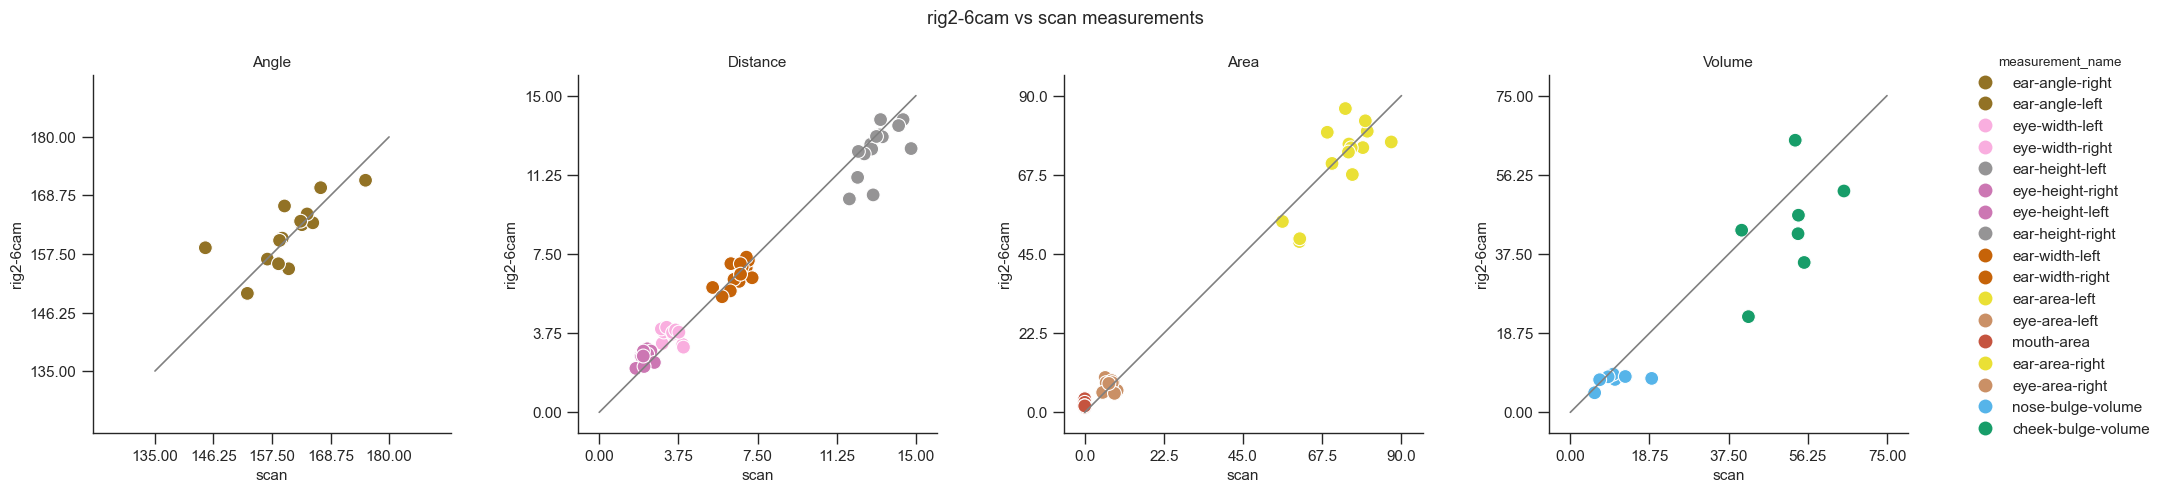

In [9]:
ax_limits = {
        'area': (0, 90),
        'distance': (0, 15),
        'volume': (0, 75),
        'angle': (135, 180)
    }


compare_setup_meas(merged_df.query("mouse != 'B21'"), 
                   'scan', 'rig2-6cam', 
                   limits = ax_limits)

## Extended Data Figure 3

### Panel b

{'ear', 'cheek', 'eye'}


/tmp/ipykernel_299902/2157068877.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


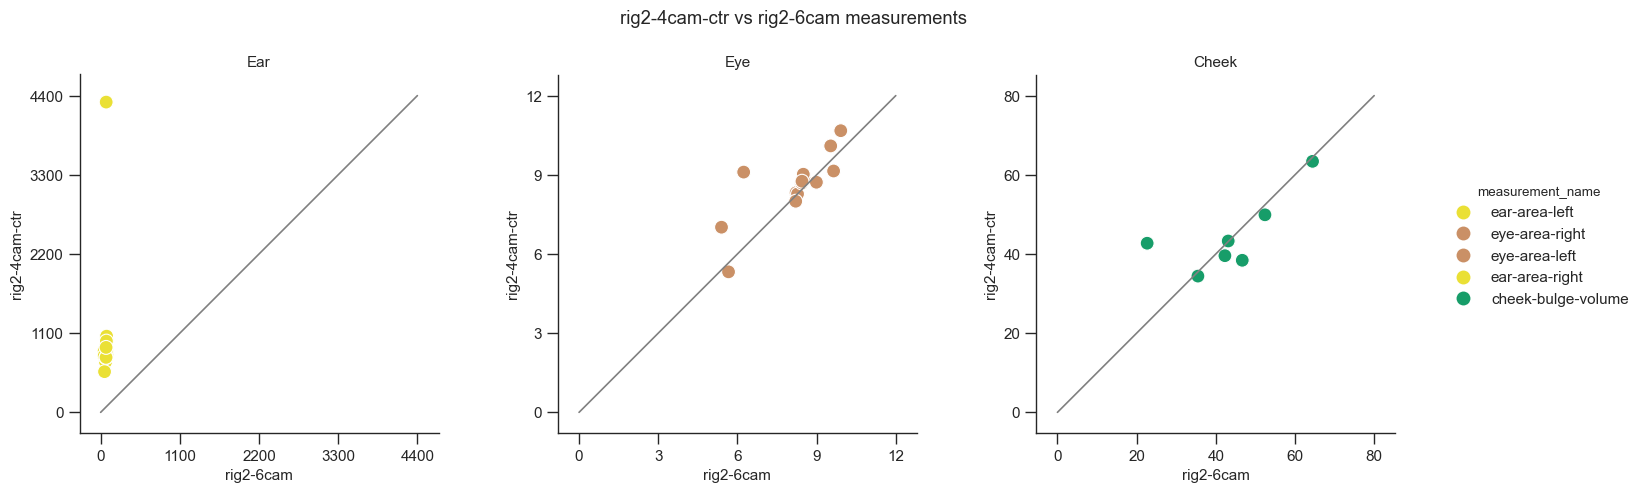

In [10]:
ax_limits = {
        'ear': (0, 4400),
        'eye': (0, 12),
        'cheek': (0, 80),
    }
measurements = ["cheek-bulge-volume", 
                "eye-area-right", 
                "eye-area-left", 
                "ear-area-right", 
                "ear-area-left",
                ]

compare_setup_meas(merged_df.query("mouse != 'B21'"), 'rig2-6cam', 'rig2-4cam-ctr', 
                   measurements = measurements, 
                   col_order = "measurement_group", limits = ax_limits)

### Panel c

{'ear', 'cheek', 'eye'}


/tmp/ipykernel_299902/2157068877.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


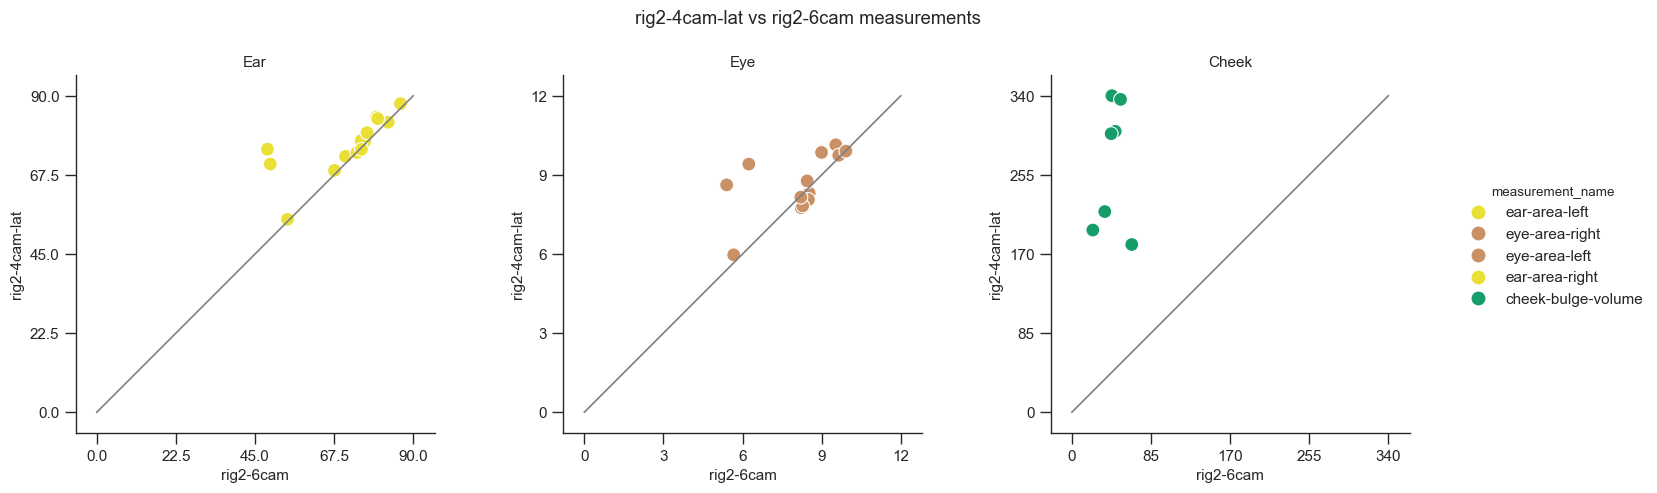

In [11]:
ax_limits = {
        'ear': (0, 90),
        'eye': (0, 12),
        'cheek': (0, 340),
    }

compare_setup_meas(merged_df.query("mouse != 'B21'"), 'rig2-6cam', 'rig2-4cam-lat', 
                   measurements = measurements, 
                   col_order = "measurement_group", limits = ax_limits)

### Panel d

{'ear', 'cheek', 'eye'}


/tmp/ipykernel_299902/2157068877.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


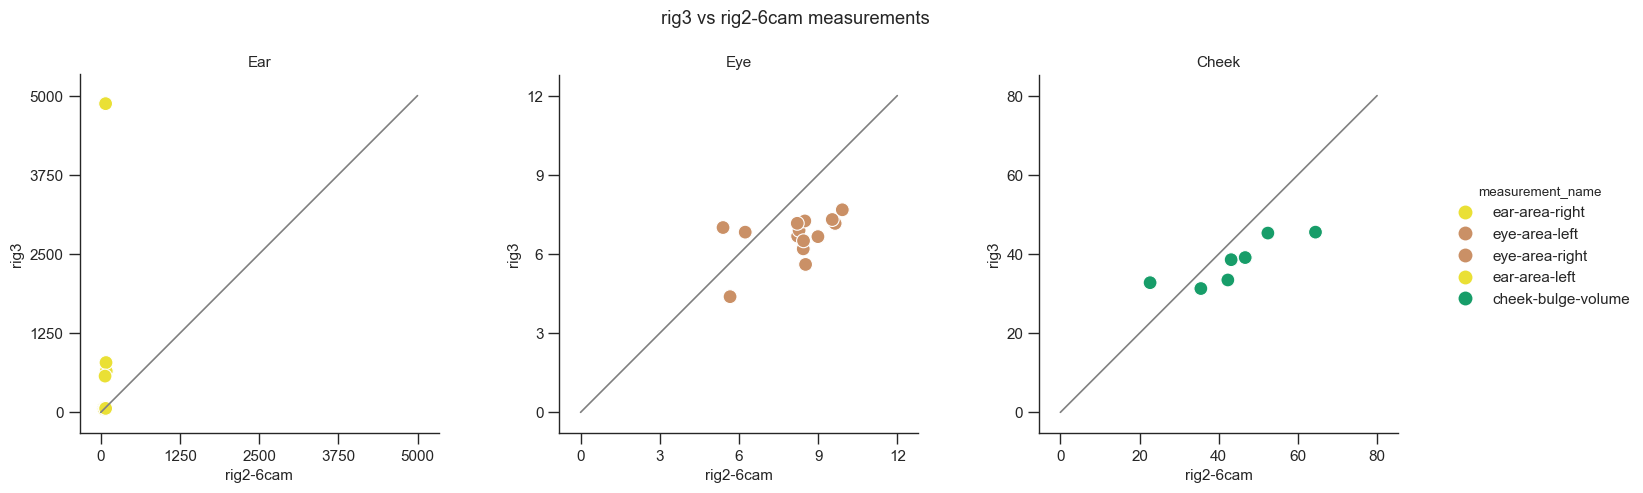

In [12]:
ax_limits = {
        'ear': (0, 5000),
        'eye': (0, 12),
        'cheek': (0, 80),
    }

compare_setup_meas(merged_df.query("mouse != 'B21'"), 'rig2-6cam', 'rig3', 
                   measurements = measurements, 
                   col_order = "measurement_group", limits = ax_limits)

In [13]:
RIGS

['rig2-6cam',
 'rig2-4cam-lat',
 'rig2-4cam-ctr',
 'rig3',
 'rig2-4cam-noRL',
 'rig2-2cam-lbc',
 'rig2-2cam-rtr',
 'rig2-2cam-tcbc',
 'rig2-2cam-tltr']

In [14]:
def compute_rmse(col1, col2):
    return np.sqrt(np.sum(((col1 - col2) ** 2))/len(col1))

rmse_list = []
for rig_layout in RIGS:
    for meas in set(merged_df['measurement_name']):
        # col1 = merged_df.query("measurement_name == @meas")["measurement_value_rig2-6cam"].values
        col11 = merged_df.query("measurement_name == @meas & source == 'rig2-6cam' & mouse != 'B21'")["measurement_value"].values
        col12 = merged_df.query("measurement_name == @meas & source == 'scan' & mouse != 'B21'")["measurement_value"].values
        col2 = merged_df.query("measurement_name == @meas & source == @rig_layout & mouse != 'B21'")[f"measurement_value"].values
        # if rig_layout in ["rig2-6cam", "rig2-4cam-ctr", "rig2-4cam-lat"] and meas == "cheek-bulge-volume":
        #     print(rig_layout, col2)
        # if rig_layout in ['rig2-2cam-lbc','rig2-2cam-tcbc','rig2-2cam-tltr']:
        #     rmse_list.append([meas, 'rig2-6cam', rig_layout, np.nan])
        #     rmse_list.append([meas, 'scan', rig_layout, np.nan]) 
        if len(col2) != 0: # and rig_layout not in ['rig2-2cam-lbc','rig2-2cam-tcbc','rig2-2cam-tltr']:
            if rig_layout != 'rig2-6cam':
                # rmse_list.append([meas, 'rig2-6cam', rig_layout, np.log10(compute_rmse(col11, col2))])
                # rmse_list.append([meas, 'scan', rig_layout, np.log10(compute_rmse(col12, col2))])
                rmse_list.append([meas, 'rig2-6cam', rig_layout, np.min([1,np.log10(compute_rmse(col11, col2))])])
                rmse_list.append([meas, 'scan', rig_layout, np.min([1,np.log10(compute_rmse(col12, col2))])])
            else:
                # rmse_list.append([meas, 'scan', rig_layout, np.log10(compute_rmse(col12, col2))])
                rmse_list.append([meas, 'scan', rig_layout, np.min([1,np.log10(compute_rmse(col12, col2))])])   
        else:
            rmse_list.append([meas, 'rig2-6cam', rig_layout, np.nan])
            rmse_list.append([meas, 'scan', rig_layout, np.nan])

rmse_df = pd.DataFrame(rmse_list, columns=['measurement', 'reference', 'setup', 'rmse'])    


### Panel e

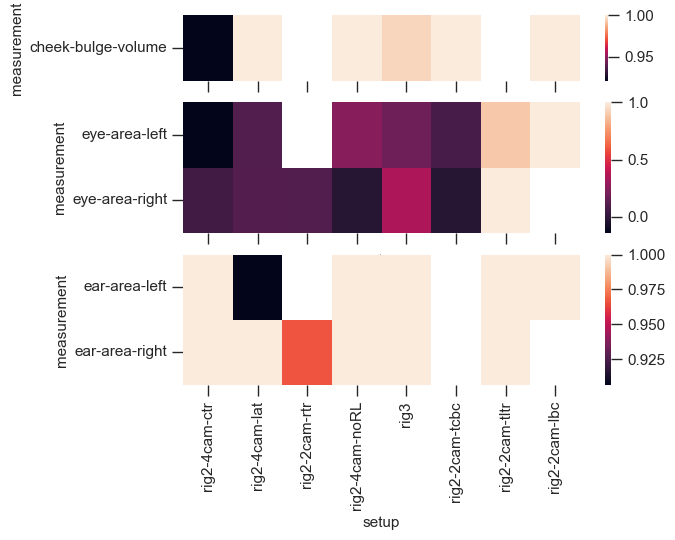

In [15]:

meas_groups = [["cheek-bulge-volume"], 
                ["eye-area-left", 
                "eye-area-right"], 
                ["ear-area-left", 
                "ear-area-right"]]

fig, axs = plt.subplots(len(meas_groups),1, gridspec_kw={'height_ratios': [1, 2, 2]}) #figsize=(12, 4))
sub_df = rmse_df.query("reference == 'rig2-6cam' & measurement in @measurements")
sub_df = sub_df.sort_values(by='measurement')
custom_order = {"rig2-4cam-ctr": 0,
                "rig2-4cam-lat": 1,
                "rig2-2cam-rtr": 2,
                "rig2-4cam-noRL": 3,
                "rig3": 4,
                "rig2-2cam-tcbc": 5,
                "rig2-2cam-tltr": 6,
                "rig2-2cam-lbc": 7}
for i, meas in enumerate(meas_groups):
    heat_df = sub_df.query("measurement in @meas")
    heat_df = heat_df.pivot(index="measurement", columns="setup", values="rmse")[list(custom_order.keys())]
    sns.heatmap(heat_df, ax = axs[i])
    axs[i].set_yticklabels(meas, rotation=0)
    if i != len(meas_groups) - 1:
        axs[i].set_xticklabels([])

file_name = 'camera-analysis-heatmap'
# save_figure("rev_figs/cam-analysis/", f"soft-limits-{file_name}-oct10", fig, formats=["svg"])

### Not part of the paper

/tmp/ipykernel_299902/1723899662.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels =  ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_299902/1723899662.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels =  ax[i].get_xticklabels(), rotation=90)
/tmp/ipykernel_299902/1723899662.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels =  ax[i].get_xticklabels(), rotation=90)


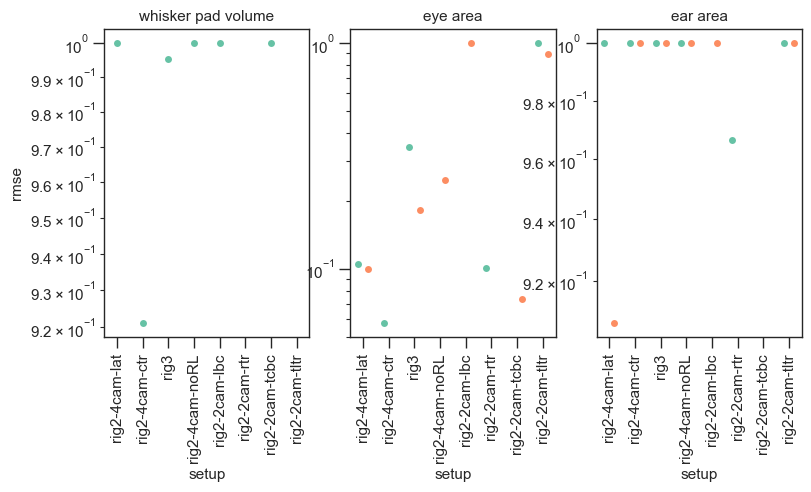

In [16]:
fig, ax = plt.subplots(1,3, figsize = (9,4))
meas_subselect = {"whisker pad volume": ['cheek-bulge-volume'],
                  "eye area": ['eye-area-right', 'eye-area-left'],
                  "ear area": ['ear-area-right', 'ear-area-left']}
for i, (meas_group, meas) in enumerate(meas_subselect.items()):
    sns.stripplot(data=rmse_df.query("measurement in @meas & " \
                                    "reference == 'rig2-6cam'"), 
                x="setup", y="rmse", 
                hue="measurement", 
                hue_order = meas,
                log_scale=True,
                dodge=True,
                legend = False,
                ax = ax[i])
    ax[i].set(title=meas_group)
    ax[i].set_xticklabels(labels =  ax[i].get_xticklabels(), rotation=90)
    if i > 0:
        ax[i].set(ylabel=None)


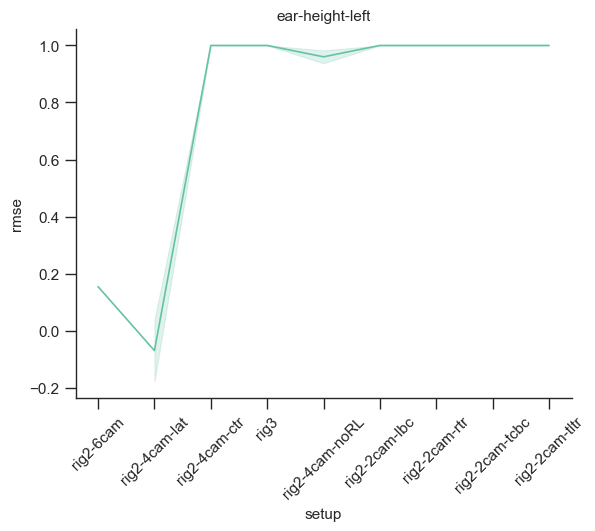

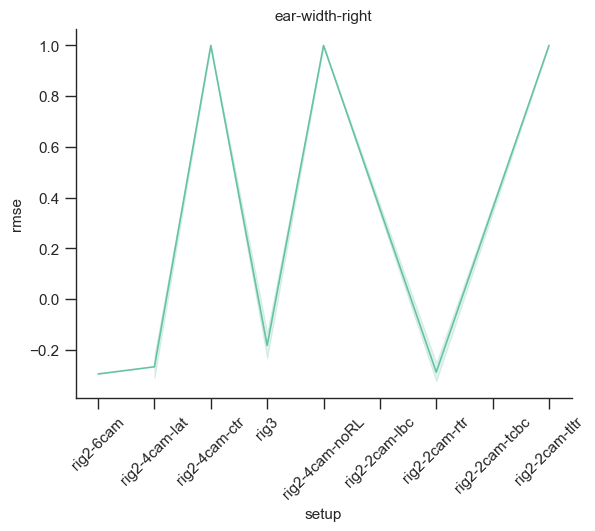

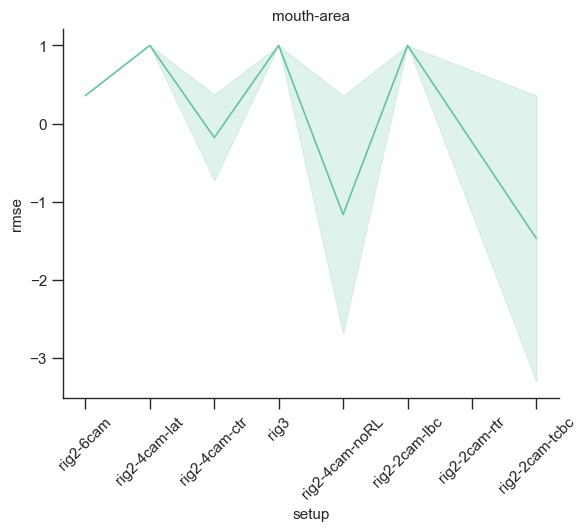

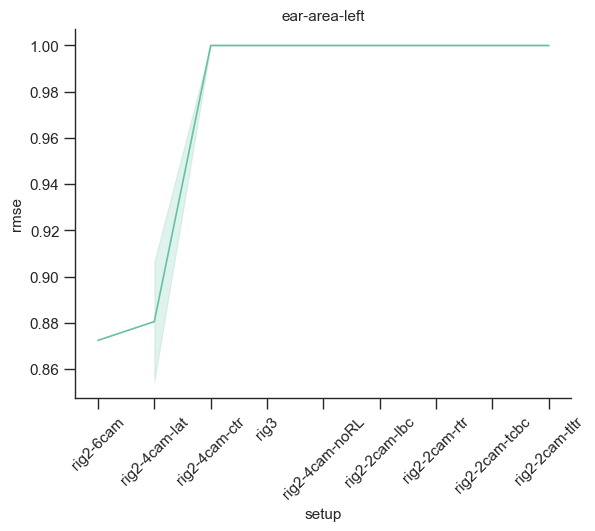

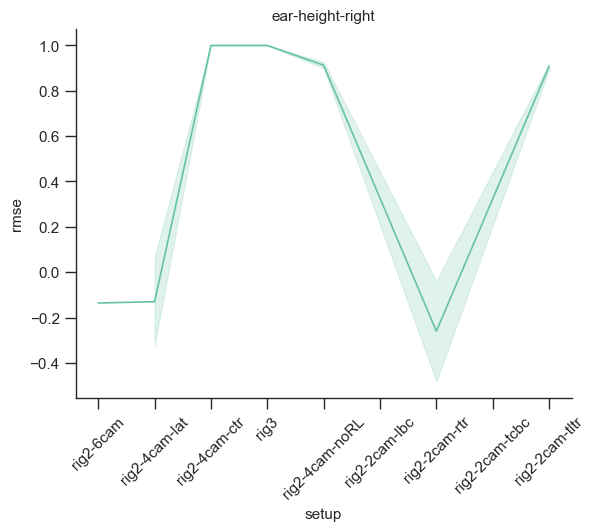

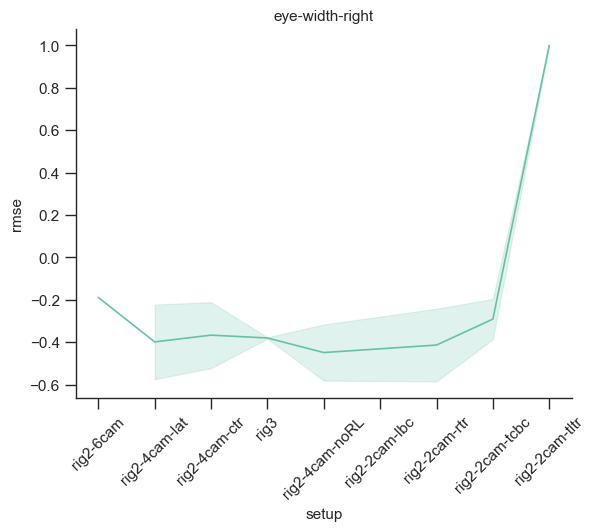

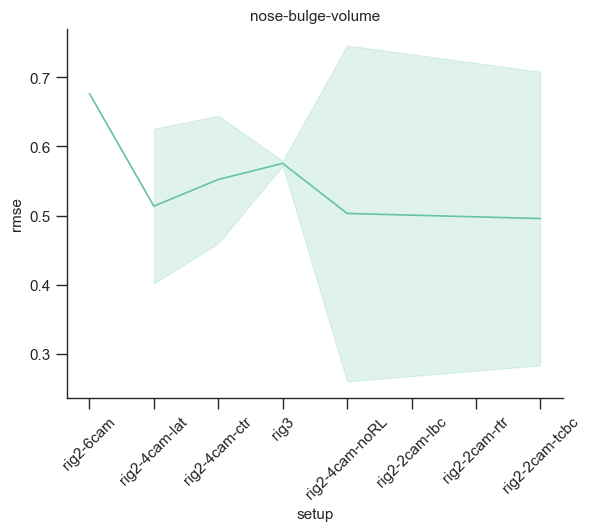

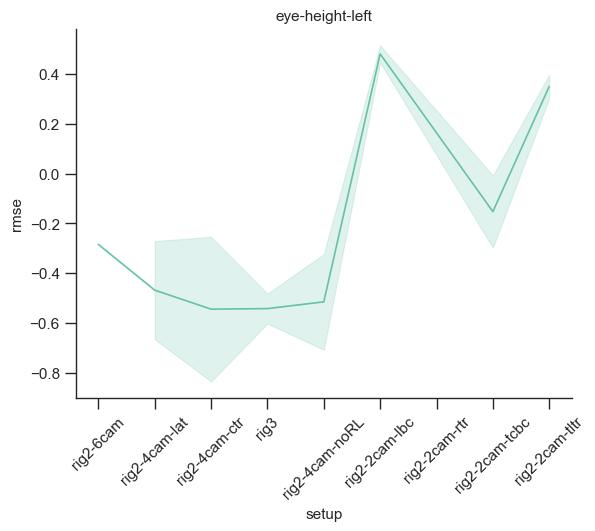

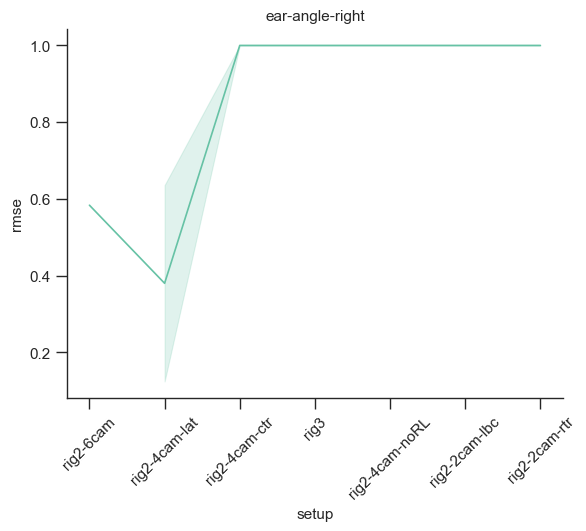

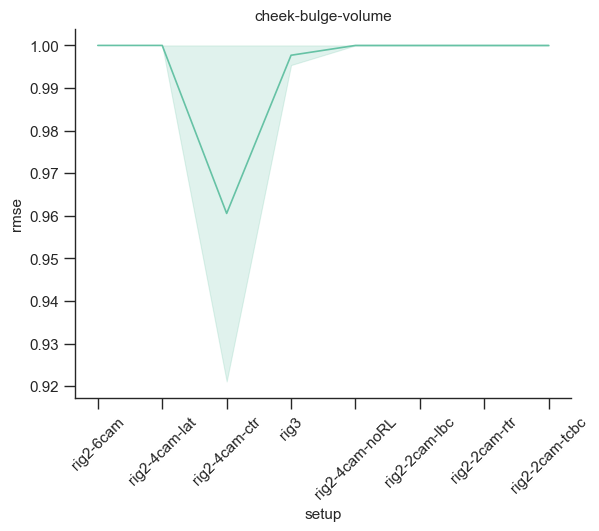

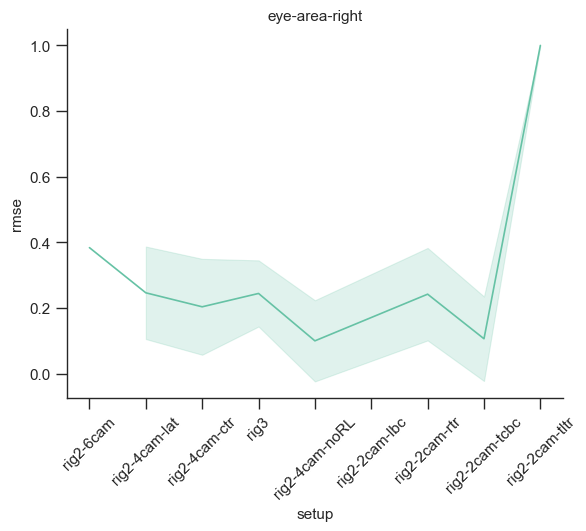

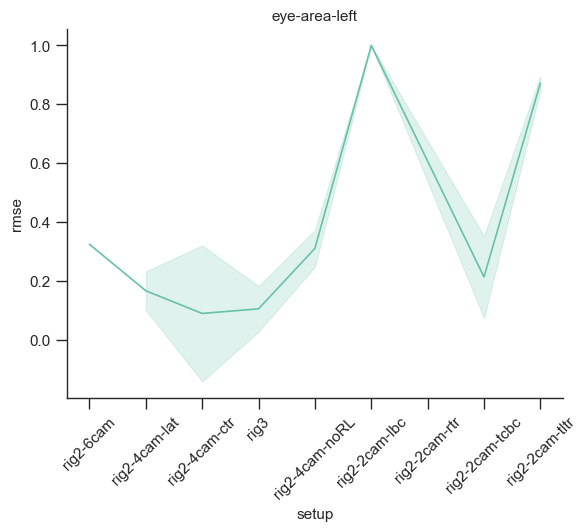

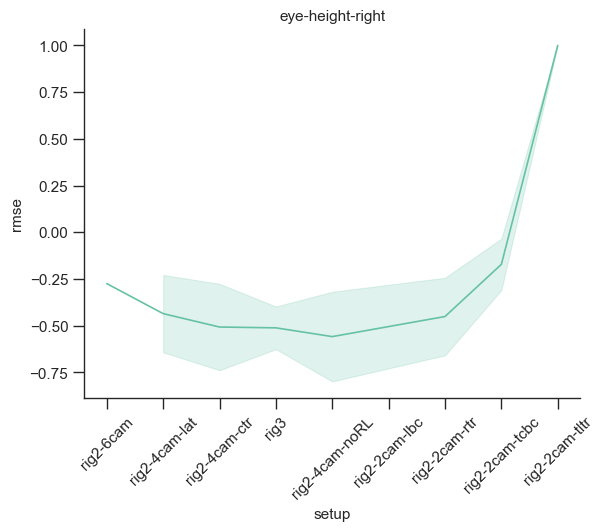

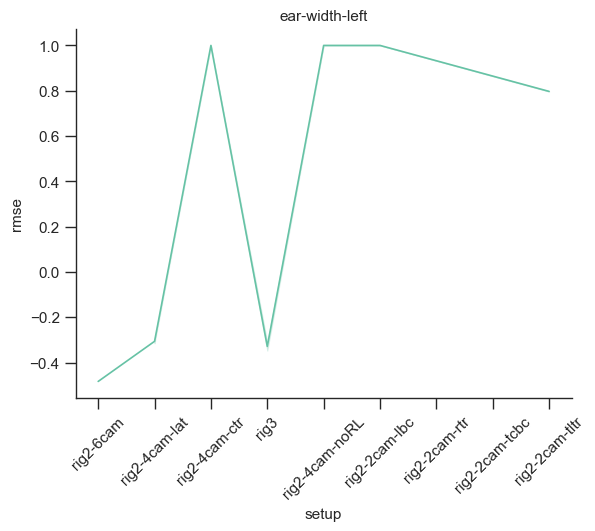

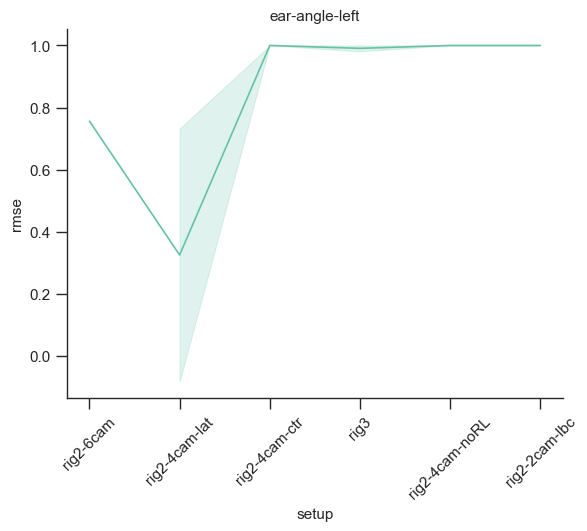

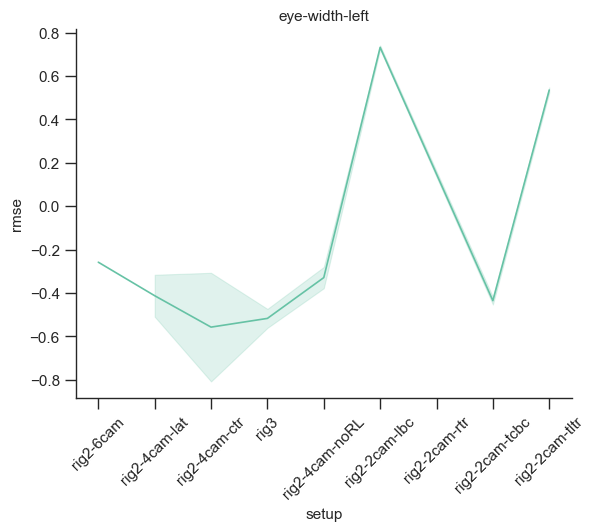

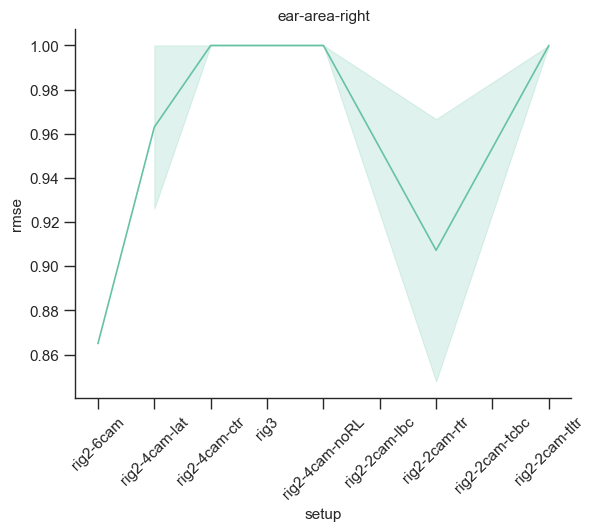

In [17]:
for meas in set(merged_df['measurement_name']):
    fig, ax = plt.subplots(1,1)
    sns.lineplot(rmse_df.query("measurement == @meas"), x = 'setup', y = 'rmse')
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=45)
    ax.set(title = meas)
